In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [3]:
filename = "SUSY-small.csv" 

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", 
            "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
            "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

In [4]:
# Exercise 3: Training a Classifier

N_Train = 400000  

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:]

X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["signal"]

X_Test = Test_Sample[VarNames[1:]]
y_Test = Test_Sample["signal"]

Test_sig = Test_Sample[Test_Sample.signal == 1]
Test_bkg = Test_Sample[Test_Sample.signal == 0]

print(f"Training samples: {len(X_Train)}")
print(f"Test samples: {len(X_Test)}")
print(f"Signal in test: {len(Test_sig)}, Background in test: {len(Test_bkg)}")

Training samples: 400000
Test samples: 100000
Signal in test: 45959, Background in test: 54041


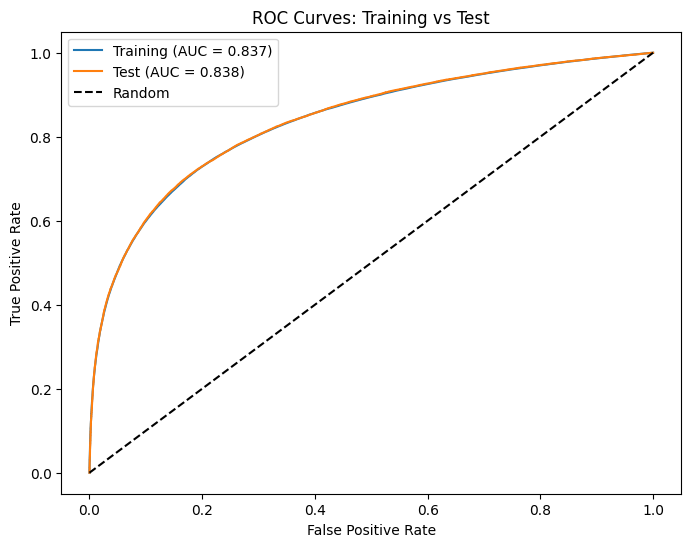

AUC Training: 0.8375
AUC Test: 0.8384
Difference: 0.0009


In [5]:
import sklearn.discriminant_analysis as DA
from sklearn.metrics import roc_curve, auc

# Training Fisher Discriminant (LDA)
Fisher = DA.LinearDiscriminantAnalysis()
Fisher.fit(X_Train, y_Train)

# Getting decision function values
train_scores = Fisher.decision_function(X_Train)
test_scores = Fisher.decision_function(X_Test)

# Computing ROC curves
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test, tpr_test, _ = roc_curve(y_Test, test_scores)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Training (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Training vs Test')
plt.legend()
plt.show()

print(f"AUC Training: {auc_train:.4f}")
print(f"AUC Test: {auc_test:.4f}")
print(f"Difference: {abs(auc_train - auc_test):.4f}")

Raw features: ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 'l_2_phi', 'MET', 'MET_phi']
Derived features: ['MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']


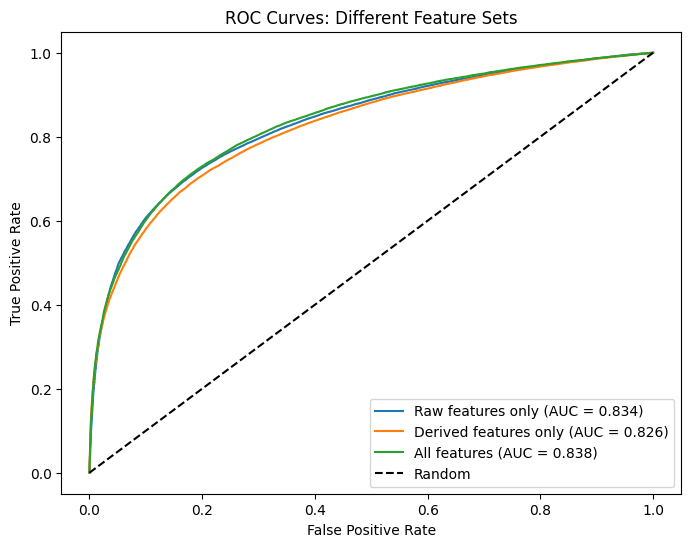

AUC Raw: 0.8344
AUC Derived: 0.8256
AUC All: 0.8384


In [6]:
# Defining feature sets
RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = [v for v in VarNames[1:] if v not in RawNames]

print("Raw features:", RawNames)
print("Derived features:", FeatureNames)

# Training classifiers on different feature sets
Fisher_raw = DA.LinearDiscriminantAnalysis()
Fisher_raw.fit(Train_Sample[RawNames], y_Train)

Fisher_features = DA.LinearDiscriminantAnalysis()
Fisher_features.fit(Train_Sample[FeatureNames], y_Train)

Fisher_all = DA.LinearDiscriminantAnalysis()
Fisher_all.fit(X_Train, y_Train)

# Computing ROC curves
# Raw features
fpr_raw, tpr_raw, _ = roc_curve(y_Test, Fisher_raw.decision_function(Test_Sample[RawNames]))
auc_raw = auc(fpr_raw, tpr_raw)

# Derived features only
fpr_feat, tpr_feat, _ = roc_curve(y_Test, Fisher_features.decision_function(Test_Sample[FeatureNames]))
auc_feat = auc(fpr_feat, tpr_feat)

# All features
fpr_all, tpr_all, _ = roc_curve(y_Test, Fisher_all.decision_function(X_Test))
auc_all = auc(fpr_all, tpr_all)

# Plot comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_raw, tpr_raw, label=f'Raw features only (AUC = {auc_raw:.3f})')
plt.plot(fpr_feat, tpr_feat, label=f'Derived features only (AUC = {auc_feat:.3f})')
plt.plot(fpr_all, tpr_all, label=f'All features (AUC = {auc_all:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Different Feature Sets')
plt.legend()
plt.show()

print(f"AUC Raw: {auc_raw:.4f}")
print(f"AUC Derived: {auc_feat:.4f}")
print(f"AUC All: {auc_all:.4f}")

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_classifier(clf, name, X_train, y_train, X_test, y_test):
    """Train and evaluate a classifier, return performance metrics"""
    
    # Train
    clf.fit(X_train, y_train)
    
    # Predict probabilities/scores
    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_test)
    elif hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X_test)[:, 1]
    else:
        scores = clf.predict(X_test)
    
    # Predict classes (using default threshold of 0)
    if hasattr(clf, "decision_function"):
        pred = (clf.decision_function(X_test) > 0).astype(int)
    elif hasattr(clf, "predict_proba"):
        pred = (clf.predict_proba(X_test)[:, 1] > 0.5).astype(int)
    else:
        pred = clf.predict(X_test)
    
    # Calculate metrics
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    return {
        'name': name,
        'AUC': roc_auc,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# Select classifiers to compare
classifiers = [
    (LogisticRegression(max_iter=1000), "Logistic Regression"),
    (RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42), "Random Forest"),
    (KNeighborsClassifier(n_neighbors=10), "KNN (k=10)"),
    (DecisionTreeClassifier(max_depth=10, random_state=42), "Decision Tree")
]

# Evaluate all classifiers
results = []
for clf, name in classifiers:
    print(f"Training {name}...")
    result = evaluate_classifier(clf, name, X_Train, y_Train, X_Test, y_Test)
    results.append(result)

# Create comparison table
table_data = [[r['name'], f"{r['AUC']:.4f}", f"{r['Accuracy']:.4f}", 
               f"{r['Precision']:.4f}", f"{r['Recall']:.4f}", f"{r['F1 Score']:.4f}"] 
              for r in results]

display(HTML(tabulate.tabulate(table_data, 
                               tablefmt='html', 
                               headers=['Classifier', 'AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])))


Training Logistic Regression...
Training Random Forest...
Training KNN (k=10)...
Training Decision Tree...


Classifier,AUC,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.8587,0.7882,0.8306,0.6772,0.7461
Random Forest,0.8654,0.7942,0.8325,0.6914,0.7554
KNN (k=10),0.8393,0.7758,0.8466,0.6255,0.7194
Decision Tree,0.8569,0.7876,0.8031,0.7127,0.7552


In [8]:
# Choosing Random Forest as the best method
best_clf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
best_clf.fit(X_Train, y_Train)

# Getting scores on test set
test_scores = best_clf.predict_proba(X_Test)[:, 1]

# Defining scenarios (N_S, N_B)
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

# Calculating maximum significance for each scenario
def max_significance(scores, y_true, N_S, N_B):
    """Find maximum significance over thresholds"""
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    
    best_sigma = 0
    best_threshold = None
    
    for i, thresh in enumerate(thresholds):
        # For each threshold, get efficiencies
        eff_S = tpr[i]  # Signal efficiency
        eff_B = fpr[i]  # Background efficiency
        
        N_S_eff = eff_S * N_S
        N_B_eff = eff_B * N_B
        
        sigma = N_S_eff / np.sqrt(N_S_eff + N_B_eff) if (N_S_eff + N_B_eff) > 0 else 0
        
        if sigma > best_sigma:
            best_sigma = sigma
            best_threshold = thresh
    
    return best_sigma, best_threshold

print("\n=== Maximum Significance for Different Scenarios (Random Forest) ===\n")
scenario_results = []
for N_S, N_B in scenarios:
    sigma_max, thresh = max_significance(test_scores, y_Test, N_S, N_B)
    scenario_results.append([N_S, N_B, f"{sigma_max:.2f}", f"{thresh:.4f}"])
    print(f"N_S={N_S:5d}, N_B={N_B:6d} -> Max σ = {sigma_max:.2f} (threshold ≈ {thresh:.4f})")

display(HTML(tabulate.tabulate(scenario_results, 
                               tablefmt='html', 
                               headers=['N_S', 'N_B', 'Max σ', 'Threshold'])))



=== Maximum Significance for Different Scenarios (Random Forest) ===

N_S=   10, N_B=   100 -> Max σ = 1.78 (threshold ≈ 0.7859)
N_S=  100, N_B=  1000 -> Max σ = 5.64 (threshold ≈ 0.7859)
N_S= 1000, N_B= 10000 -> Max σ = 17.84 (threshold ≈ 0.7859)
N_S=10000, N_B=100000 -> Max σ = 56.42 (threshold ≈ 0.7859)


N_S,N_B,Max σ,Threshold
10,100,1.78,0.7859
100,1000,5.64,0.7859
1000,10000,17.84,0.7859
10000,100000,56.42,0.7859


In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def get_all_metrics(clf, X_train, y_train, X_test, y_test, scenario_N_S, scenario_N_B):
    """Compute all metrics including significance for a given scenario"""
    
    clf.fit(X_train, y_train)
    scores = clf.predict_proba(X_test)[:, 1]
    
    # ROC metrics
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    
    # Precision-Recall metrics
    precision, recall, pr_thresholds = precision_recall_curve(y_test, scores)
    avg_precision = average_precision_score(y_test, scores)
    
    # Finding optimal threshold for this scenario
    best_sigma = 0
    best_metrics = {}
    
    for i, thresh in enumerate(thresholds):
        eff_S = tpr[i]
        eff_B = fpr[i]
        
        N_S_eff = eff_S * scenario_N_S
        N_B_eff = eff_B * scenario_N_B
        
        sigma = N_S_eff / np.sqrt(N_S_eff + N_B_eff) if (N_S_eff + N_B_eff) > 0 else 0
        
        if sigma > best_sigma:
            best_sigma = sigma
            # Predictions at this threshold
            pred = (scores > thresh).astype(int)
            best_metrics = {
                'threshold': thresh,
                'eff_S': eff_S,
                'eff_B': eff_B,
                'N_S_eff': N_S_eff,
                'N_B_eff': N_B_eff,
                'significance': sigma,
                'accuracy': accuracy_score(y_test, pred),
                'precision': precision_score(y_test, pred, zero_division=0),
                'recall': recall_score(y_test, pred, zero_division=0),
                'f1': f1_score(y_test, pred, zero_division=0)
            }
    
    return {
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'best_sigma': best_sigma,
        'best_metrics': best_metrics
    }

# Using Random Forest as the best method
best_clf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)

# Evaluating for each scenario
all_scenario_results = []

for N_S, N_B in scenarios:
    print(f"\nEvaluating scenario: N_S={N_S}, N_B={N_B}")
    metrics = get_all_metrics(best_clf, X_Train, y_Train, X_Test, y_Test, N_S, N_B)
    
    result = {
        'N_S': N_S,
        'N_B': N_B,
        'AUC': metrics['roc_auc'],
        'Avg Precision': metrics['avg_precision'],
        'Max σ': metrics['best_sigma'],
        'Optimal Threshold': f"{metrics['best_metrics']['threshold']:.4f}",
        'ε_S': f"{metrics['best_metrics']['eff_S']:.4f}",
        'ε_B': f"{metrics['best_metrics']['eff_B']:.4f}",
        'N_S_eff': f"{metrics['best_metrics']['N_S_eff']:.1f}",
        'N_B_eff': f"{metrics['best_metrics']['N_B_eff']:.1f}",
        'Accuracy': f"{metrics['best_metrics']['accuracy']:.4f}",
        'Precision': f"{metrics['best_metrics']['precision']:.4f}",
        'Recall': f"{metrics['best_metrics']['recall']:.4f}",
        'F1': f"{metrics['best_metrics']['f1']:.4f}"
    }
    all_scenario_results.append(result)

# Creating formatted table
table_headers = ['N_S', 'N_B', 'AUC', 'Avg Prec', 'Max σ', 'Thresh', 'ε_S', 'ε_B', 
                 'N_S_eff', 'N_B_eff', 'Acc', 'Prec', 'Rec', 'F1']

table_data = [[r['N_S'], r['N_B'], f"{r['AUC']:.4f}", f"{r['Avg Precision']:.4f}",
               f"{r['Max σ']:.2f}", r['Optimal Threshold'], r['ε_S'], r['ε_B'],
               r['N_S_eff'], r['N_B_eff'], r['Accuracy'], r['Precision'], 
               r['Recall'], r['F1']] for r in all_scenario_results]

display(HTML(tabulate.tabulate(table_data, tablefmt='html', headers=table_headers)))




Evaluating scenario: N_S=10, N_B=100

Evaluating scenario: N_S=100, N_B=1000

Evaluating scenario: N_S=1000, N_B=10000

Evaluating scenario: N_S=10000, N_B=100000


N_S,N_B,AUC,Avg Prec,Max σ,Thresh,ε_S,ε_B,N_S_eff,N_B_eff,Acc,Prec,Rec,F1
10,100,0.8654,0.8705,1.78,0.7859,0.4552,0.0196,4.6,2,0.739,0.9519,0.4551,0.6158
100,1000,0.8654,0.8705,5.64,0.7859,0.4552,0.0196,45.5,19.6,0.739,0.9519,0.4551,0.6158
1000,10000,0.8654,0.8705,17.84,0.7859,0.4552,0.0196,455.2,195.8,0.739,0.9519,0.4551,0.6158
10000,100000,0.8654,0.8705,56.42,0.7859,0.4552,0.0196,4551.7,1957.8,0.739,0.9519,0.4551,0.6158


In [12]:
print("SUMMARY OF RESULTS")

print("\n1. LDA Classifier Performance:")
print(f"   - Training AUC: {auc_train:.4f}")
print(f"   - Test AUC: {auc_test:.4f}")
print("   - No significant overfitting detected")

print("\n2. Feature Set Comparison:")
print(f"   - Raw features only AUC: {auc_raw:.4f}")
print(f"   - Derived features only AUC: {auc_feat:.4f}")
print(f"   - All features AUC: {auc_all:.4f}")

print("\n3. Classifier Comparison (AUC):")
for r in results:
    print(f"   - {r['name']}: {r['AUC']:.4f}")

print("\n4. Best classifier: Random Forest")
print("5. Significance achieved for different scenarios:")
for r in all_scenario_results:
    print(f"   - N_S={r['N_S']:5d}, N_B={r['N_B']:6d}: σ = {r['Max σ']:.2f}")

SUMMARY OF RESULTS

1. LDA Classifier Performance:
   - Training AUC: 0.8375
   - Test AUC: 0.8384
   - No significant overfitting detected

2. Feature Set Comparison:
   - Raw features only AUC: 0.8344
   - Derived features only AUC: 0.8256
   - All features AUC: 0.8384

3. Classifier Comparison (AUC):
   - Logistic Regression: 0.8587
   - Random Forest: 0.8654
   - KNN (k=10): 0.8393
   - Decision Tree: 0.8569

4. Best classifier: Random Forest
5. Significance achieved for different scenarios:
   - N_S=   10, N_B=   100: σ = 1.78
   - N_S=  100, N_B=  1000: σ = 5.64
   - N_S= 1000, N_B= 10000: σ = 17.84
   - N_S=10000, N_B=100000: σ = 56.42
